<a href="https://colab.research.google.com/github/tehnik-tehnolog/Notebooks/blob/main/bilingual_ocr_ru_en_synthetic_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#

### Config

In [1]:
!pip install Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.8 MB/s eta 0:00:00


In [2]:
import csv
import colorsys
import os
import random
import pickle
import urllib.request
from fontTools.ttLib import TTFont
from PIL import Image, ImageDraw, ImageFilter, ImageFont
from faker import Faker

In [3]:
HF_TOKEN = "hf_..."  # <-- your token
HF_REPO  = "tehnik-tehnolog/bilingual-ocr-ru-en-synthetic"

DATASET_DIR = "bilingual-ocr-ru-en-synthetic"
SPLITS = ["train", "val", "test"]
CLASSES = ["cyrillic", "latin"]
SPLIT_RATIOS = {"train": 0.8, "val": 0.1, "test": 0.1}
TOTAL_SAMPLES_PER_LANG = 200000

RU_URL = "https://raw.githubusercontent.com/tehnik-tehnolog/Notebooks/main/OCR/all_ru_keywords.txt"
EN_URL = "https://raw.githubusercontent.com/tehnik-tehnolog/Notebooks/main/OCR/all_en_keywords.txt"
RU_PATH = "all_ru_keywords.txt"
EN_PATH = "all_en_keywords.txt"

BASE_FONTS_URL = (
    "https://raw.githubusercontent.com/tehnik-tehnolog/Notebooks/main/"
    "OCR/bilingual_ttf_25_fonts_ru-en_75_ttf/TTF/"
)

FONT_FAMILIES = [
    "Arimo", "Fira-Sans", "Noto-Serif", "IBM-Plex-Sans", "Inter", "Manrope",
    "Merriweather", "Montserrat", "Noto-Sans", "Open-Sans", "Playfair-Display",
    "PT-Sans", "PT-Serif", "Roboto", "Carlito", "Tinos", "DejaVu-Sans", "Cousine",
    "Fira-Code", "IBM-Plex-Mono", "JetBrains-Mono", "PT-Mono", "Source-Code-Pro",
    "STIX-Two-Math",
]

FULL_MATH_FONTS = [
    "Arimo", "Carlito", "Tinos", "DejaVu-Sans", "Cousine",
    "Fira-Code", "Source-Code-Pro", "STIX-Two-Math",
]

### Vocabularity & keywords

In [4]:
# Vocabularity
MATH_SYMBOLS = [
    "∑", "∏", "∫", "√", "∂", "∞", "≈", "≠", "±", "λ", "μ", "π",
    "+", "−", "×", "*", "÷", "=", "<", ">", "≤", "≥", "∩",
    "α", "β", "γ", "δ", "ε", "ζ", "η", "θ", "ν", "ξ", "ρ", "σ", "τ", "φ", "ψ", "ω",
    "Δ", "Θ", "Λ", "Ψ", "Ω", "ϑ", "&", "%"
]
MATH_SYMBOLS_SET = set(MATH_SYMBOLS)

PUNCTUATION_COMMON = [
    "-", "–", "=", "(", ")", ",", ".", ":", ";", "!", "?", "@",
    "‐", "‑", "‒", "—", "―", "−", "~", "„", "“", "#"
]

SHORT_RU = [
    "и", "в", "во", "не", "на", "я", "с", "со", "что", "а", "по", "но", "к", "ко",
    "у", "же", "за", "бы", "от", "из", "до", "о", "об", "так", "его", "все", "всё",
    "ее", "её", "при", "или", "ей", "ему", "им", "их", "мы", "вы", "он", "она",
    "оно", "они", "где", "как", "кто", "чем", "без", "над", "под", "для", "про",
    "да", "нет", "ли", "ни", "ну", "вот", "ведь", "уж", "уже", "еще", "ещё",
    "тоже", "там", "тут", "тот", "та", "те", "то", "ту", "это", "эта", "эти",
    "этот", "себя", "себе", "собой", "свой", "своя", "свое", "своё", "свои",
    "наш", "наша", "наше", "наши", "нас", "нам", "ваш", "ваша", "ваше", "ваши",
    "вас", "вам", "мой", "моя", "мое", "моё", "мои", "меня", "мне", "мной",
    "твой", "твоя", "твое", "твоё", "твои", "тебя", "тебе", "тобой", "него",
    "нему", "ним", "ней", "нею", "нее", "неё", "них", "ими", "кого", "кому",
    "кем", "чего", "чему", "чём", "том", "того", "тому", "тем", "тех", "этих",
    "этим", "этими", "такой", "такая", "такое", "такие", "один", "два", "три",
    "куда", "почему", "какой", "здесь", "туда", "близ", "вдоль", "вне", "кроме",
    "меж", "мимо", "ради", "чрез", "через", "среди", "после", "перед", "около",
    "между", "сквозь", "вроде", "вместо", "вслед", "поверх", "позади", "прежде",
    "из-за", "из-под", "либо", "если", "чтобы", "хоть", "хотя", "будто", "словно",
    "точно", "когда", "пока", "едва", "лишь", "только", "зато", "притом",
    "причем", "также", "раз", "нежели", "коли", "кабы", "дабы", "вон", "мол",
    "пусть", "пускай", "давай", "просто", "прямо", "именно", "почти", "даже",
    "разве", "аж", "ин", "сюда", "всюду", "везде", "нигде", "никуда", "никогда",
    "всегда", "иногда", "часто", "редко", "скоро", "быстро", "тихо", "громко",
    "хорошо", "плохо", "много", "мало", "очень", "слишком", "совсем", "чуть",
    "теперь", "тогда", "потом", "снова", "опять", "вновь", "наконец", "вообще",
    "сам", "сама", "само", "сами", "самый", "самая", "самое", "самые", "весь",
    "вся", "всего", "всему", "всем", "всех", "всеми", "всею", "чей", "чья",
    "чье", "чьё", "чьи", "чьего", "чьему", "чьим", "чьих", "никто", "ничто",
    "некто", "нечто", "некий", "некая", "некое", "некие", "никакой", "ничей",
    "ничья", "ничье", "ничьи", "сей", "сия", "сие", "сии", "четыре", "пять",
    "шесть", "семь", "восемь", "девять", "десять", "оба", "обе", "двое", "трое",
    "четверо", "пятеро", "шестеро", "семеро", "восьмеро", "девятеро", "десятеро",
    "сколько", "столько", "несколько", "есть", "был", "была", "было", "были",
    "быть", "буду", "будешь", "будет", "будем", "будете", "будут", "будь",
    "будьте", "дай", "дам", "даст", "дашь", "дал", "дала", "дало", "дали",
    "можно", "нельзя", "надо", "нужно", "может", "хочешь", "хочу", "хочет",
    "хотим", "хотите", "хотят", "какая", "какое", "какие", "что-то", "кто-то",
    "где-то", "как-то", "куда-то", "когда-то", "кое-как", "кое-где", "кое-что",
    "кое-кто",
]

SHORT_EN = [
    "a", "an", "the", "and", "or", "but", "so", "for", "in", "on", "at", "to",
    "of", "by", "with", "from", "up", "down", "off", "out", "over", "under",
    "into", "as", "if", "then", "than", "that", "this", "these", "those",
    "there", "here", "where", "when", "why", "how", "what", "which", "who",
    "is", "am", "are", "was", "were", "be", "been", "being", "do", "does",
    "did", "done", "doing", "have", "has", "had", "having", "will", "would",
    "can", "could", "shall", "may", "might", "must", "not", "no", "any", "all",
    "both", "each", "few", "more", "most", "some", "such", "own", "same",
    "other", "very", "too", "just", "only", "even", "also", "still", "ever",
    "never", "soon", "again", "once", "now", "me", "my", "mine", "myself",
    "you", "your", "yours", "yourself", "he", "him", "his", "himself", "she",
    "her", "hers", "herself", "it", "its", "itself", "we", "us", "our", "ours",
    "they", "them", "their", "about", "after", "before", "since", "until",
    "while", "above", "below", "between", "among", "through", "during",
    "around", "behind", "near", "next", "past", "i", "whom", "whose", "theirs",
    "ourselves", "yourselves", "themselves", "every", "either", "neither",
    "none", "one", "two", "three", "four", "five", "six", "seven", "eight",
    "nine", "ten", "many", "much", "little", "less", "least", "another",
    "others", "anybody", "anyone", "anything", "everybody", "everyone",
    "everything", "nobody", "nothing", "somebody", "someone", "something",
    "aboard", "across", "against", "along", "amid", "atop", "beneath",
    "beside", "besides", "beyond", "except", "inside", "like", "onto",
    "opposite", "outside", "per", "throughout", "till", "toward", "towards",
    "underneath", "upon", "via", "within", "without", "nor", "yet", "although",
    "because", "unless", "whereas", "whether", "though", "quite", "rather",
    "almost", "enough", "far", "fast", "slow", "well", "badly", "today",
    "tomorrow", "yesterday", "twice", "forever", "maybe", "perhaps", "indeed",
    "instead", "anyway", "however", "therefore", "thus", "hence", "otherwise",
    "likewise", "meanwhile", "moreover", "furthermore", "should", "ought",
    "need", "dare", "let", "make", "go", "get", "put", "run", "see", "say",
    "said", "says", "got", "give", "take", "come", "came", "goes", "went",
    "gone", "made", "know", "knew", "think", "thought", "want", "wanted",
    "use", "used", "find", "found", "tell", "told", "ask", "asked", "work",
    "worked", "seem", "seemed", "feel", "felt", "try", "tried", "leave",
    "left", "call", "called", "yes", "whatever", "whichever", "whoever",
    "whomever",
]

# Keywords
def download(url, path):
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
    return path


def load_keywords(path):
    with open(path, "r", encoding="utf-8") as f:
        return [w.strip() for w in f.read().split("|") if w.strip()]


download(RU_URL, RU_PATH)
download(EN_URL, EN_PATH)
RU_KEYWORDS = load_keywords(RU_PATH)
EN_KEYWORDS = load_keywords(EN_PATH)

### Fronts, colors & text generation

In [5]:
# Fronts
os.makedirs("fonts", exist_ok=True)

ALL_FONTS = []
for family in FONT_FAMILIES:
    for style in ("Regular", "Bold", "Italic"):
        fname = f"{family}-{style}.ttf"
        fpath = os.path.join("fonts", fname)
        if not os.path.exists(fpath):
            try:
                urllib.request.urlretrieve(BASE_FONTS_URL + fname, fpath)
            except Exception:
                continue
        if os.path.exists(fpath):
            ALL_FONTS.append(fpath)

# Unicode coverage maps (avoids tofu boxes)
FONT_UNICODES = {}
for fpath in ALL_FONTS:
    try:
        cmap = TTFont(fpath).getBestCmap()
        FONT_UNICODES[fpath] = set(cmap.keys()) if cmap else set()
    except Exception:
        FONT_UNICODES[fpath] = set()

FULL_MATH_SUPPORT_FONTS = [
    f for f in ALL_FONTS
    if any(name in os.path.basename(f) for name in FULL_MATH_FONTS)
]

_FONT_CACHE = {}


def get_font(path, size):
    key = (path, size)
    if key not in _FONT_CACHE:
        _FONT_CACHE[key] = ImageFont.truetype(path, size)
    return _FONT_CACHE[key]


def has_glyph(font_path, char):
    # Accurately checking for the presence of a Unicode glyph using CMAP from fontTools
    return ord(char) in FONT_UNICODES.get(font_path, set())


def find_font_for_char(char, size, primary=None):
    # It looks for a font that is guaranteed to support the character
    if primary and has_glyph(primary, char):
        return get_font(primary, size), primary

    pool = FULL_MATH_SUPPORT_FONTS + [f for f in ALL_FONTS if f not in FULL_MATH_SUPPORT_FONTS]
    for fpath in pool:
        if has_glyph(fpath, char):
            return get_font(fpath, size), fpath
    return None, None


def resolve_fonts(text, size):
    """Returns per-character font mapping, ensuring every glyph is renderable."""
    normal_chars = [c for c in text if c not in MATH_SYMBOLS_SET and c != " "]
    shuffled = list(ALL_FONTS)
    random.shuffle(shuffled)

    primary_path, primary_obj = None, None
    for fpath in shuffled:
        if all(has_glyph(fpath, c) for c in normal_chars):
            primary_path = fpath
            primary_obj = get_font(fpath, size)
            break

    if primary_path is None and ALL_FONTS:
        primary_path = ALL_FONTS[0]
        primary_obj = get_font(primary_path, size)

    mapping = []
    for char in text:
        if char == " ":
            mapping.append((char, primary_obj, primary_path))
        elif primary_path and has_glyph(primary_path, char):
            mapping.append((char, primary_obj, primary_path))
        else:
            obj, path = find_font_for_char(char, size, primary_path)
            if obj is None:
                return None, None
            mapping.append((char, obj, path))
    return mapping, primary_path

# Color & text
def get_relative_luminance(rgb):
    r, g, b = [c / 255.0 for c in rgb]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def get_random_color_pair():
    if random.random() < 0.60:
        if random.random() < 0.5:
            bg = tuple(random.randint(230, 255) for _ in range(3))
            fg = tuple(random.randint(0, 40) for _ in range(3))
        else:
            bg = tuple(random.randint(15, 40) for _ in range(3))
            fg = tuple(random.randint(220, 255) for _ in range(3))
        return bg, fg

    while True:
        bg = tuple(random.randint(0, 255) for _ in range(3))
        fg = tuple(random.randint(0, 255) for _ in range(3))
        if abs(get_relative_luminance(bg) - get_relative_luminance(fg)) > 0.45:
            return bg, fg

_FAKER_CACHE = {}

def get_faker(lang):
    if lang not in _FAKER_CACHE:
        _FAKER_CACHE[lang] = Faker(lang)
    return _FAKER_CACHE[lang]

def generate_text(vocab, lang="ru_RU"):
    faker_obj = get_faker(lang)
    short = SHORT_RU if lang == "ru_RU" else SHORT_EN
    p = random.random()

    if p < 0.30:
        word = random.choice(short)
    elif p < 0.75:
        word = random.choice(vocab) if (vocab and random.random() < 0.5) else faker_obj.word()
    elif p < 0.90:
        word = f"{random.choice(short)} {faker_obj.word()}"
    else:
        # Mathematical symbols are generated only for the Latin alphabet
        if lang == "en_US":
            var = random.choice(["x", "y", "n", "a", "b", "c", "k", "f(x)", "g(x)", "α", "β", "λ"])
            sym = random.choice(MATH_SYMBOLS)
            word = random.choice([f"{sym}{var}", f"{var} {sym} 2", f"{sym}({var})", f"{var}_{sym}"])
        else:
            word = faker_obj.word()

    # Add digits
    if random.random() < 0.25:
        num = str(random.randint(0, 999))
        kind = random.choice(["suffix", "prefix", "code"])
        word = {"suffix": f"{word}{num}", "prefix": f"{num} {word}", "code": f"{word}-{num}"}[kind]

    # Add punctuation
    if random.random() < 0.20:
        punct = random.choice(PUNCTUATION_COMMON)
        word = f"{word}{punct}" if random.random() < 0.7 else f"{punct}{word}"

    return word.upper() if random.random() < 0.15 else word

### Render

In [6]:
def render_word(text):
    font_size = random.randint(18, 34)

    char_font_map, primary_font_path = resolve_fonts(text, font_size)
    if char_font_map is None:
        return None, None

    dummy_img = Image.new("RGB", (1, 1))
    draw_dummy = ImageDraw.Draw(dummy_img)

    char_render_info = []
    total_width = 0
    max_ascent = 0
    max_descent = 0

    for char, font_obj, f_path in char_font_map:
        # Calculate character width (length accounts for font side bearings)
        w = draw_dummy.textlength(char, font=font_obj)
        if w == 0 and char == " ":
            w = font_size // 3

        ascent, descent = font_obj.getmetrics()
        max_ascent = max(max_ascent, ascent)
        max_descent = max(max_descent, descent)

        char_render_info.append({
            "char": char,
            "font_obj": font_obj,
            "width": max(w, 1),
        })
        total_width += max(w, 1)

    if total_width <= 0:
        return None, None

    pad_x, pad_y = random.randint(6, 12), random.randint(4, 10)
    img_w = int(total_width) + pad_x * 2
    img_h = (max_ascent + max_descent) + pad_y * 2

    bg_color, fg_color = get_random_color_pair()
    img = Image.new("RGB", (img_w, img_h), color=bg_color)
    draw = ImageDraw.Draw(img)

    curr_x = pad_x
    # Fixed baseline Y-coordinate for all characters in the word
    baseline_y = pad_y + max_ascent

    for item in char_render_info:
        char = item["char"]
        f_obj = item["font_obj"]

        # anchor="ls" aligns the character strictly to the baseline
        draw.text((curr_x, baseline_y), char, fill=fg_color, font=f_obj, anchor="ls")
        curr_x += item["width"]

    if random.random() < 0.50:
        angle = random.uniform(-3.0, 3.0)
        img = img.rotate(angle, resample=Image.BICUBIC, expand=True, fillcolor=bg_color)

    if random.random() < 0.15:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 0.6)))

    meta = {
        "text": text,
        "width": img.width,
        "height": img.height,
        "aspect_ratio": round(img.width / img.height, 3),
        "font_name": os.path.basename(primary_font_path),
        "font_size": font_size,
    }

    return img, meta


def assign_split():
    p = random.random()
    if p < SPLIT_RATIOS["train"]:
        return "train"
    if p < SPLIT_RATIOS["train"] + SPLIT_RATIOS["val"]:
        return "val"
    return "test"

### Main generation loop

In [7]:
def generate_dataset():
    for split in SPLITS:
        for cls in CLASSES:
            os.makedirs(os.path.join(DATASET_DIR, split, cls), exist_ok=True)

    manifest = os.path.join(DATASET_DIR, "dataset_manifest.csv")
    headers = ["filepath", "split", "label", "text", "width", "height",
               "aspect_ratio", "font_name", "font_size"]

    with open(manifest, "w", encoding="utf-8", newline="") as f_csv:
        writer = csv.DictWriter(f_csv, fieldnames=headers)
        writer.writeheader()

        for lang, vocab, cls in [("ru_RU", RU_KEYWORDS, "cyrillic"),
                                 ("en_US", EN_KEYWORDS, "latin")]:
            count = skipped = 0
            print(f"Generating class: {cls}...")

            while count < TOTAL_SAMPLES_PER_LANG:
                text = generate_text(vocab, lang)
                img, meta = render_word(text)
                if img is None:
                    skipped += 1
                    continue

                split = assign_split()
                rel_path = os.path.join(split, cls, f"{cls}_{count:06d}.png")
                img.save(os.path.join(DATASET_DIR, rel_path))

                meta.update({"filepath": rel_path, "split": split, "label": cls})
                writer.writerow(meta)
                count += 1

            print(f"  {cls} done. Skipped: {skipped}")

    print(f"Dataset ready: {manifest}")

generate_dataset()

Generating class: cyrillic...
  cyrillic done. Skipped: 0
Generating class: latin...
  latin done. Skipped: 0
Dataset ready: bilingual-ocr-ru-en-synthetic/dataset_manifest.csv


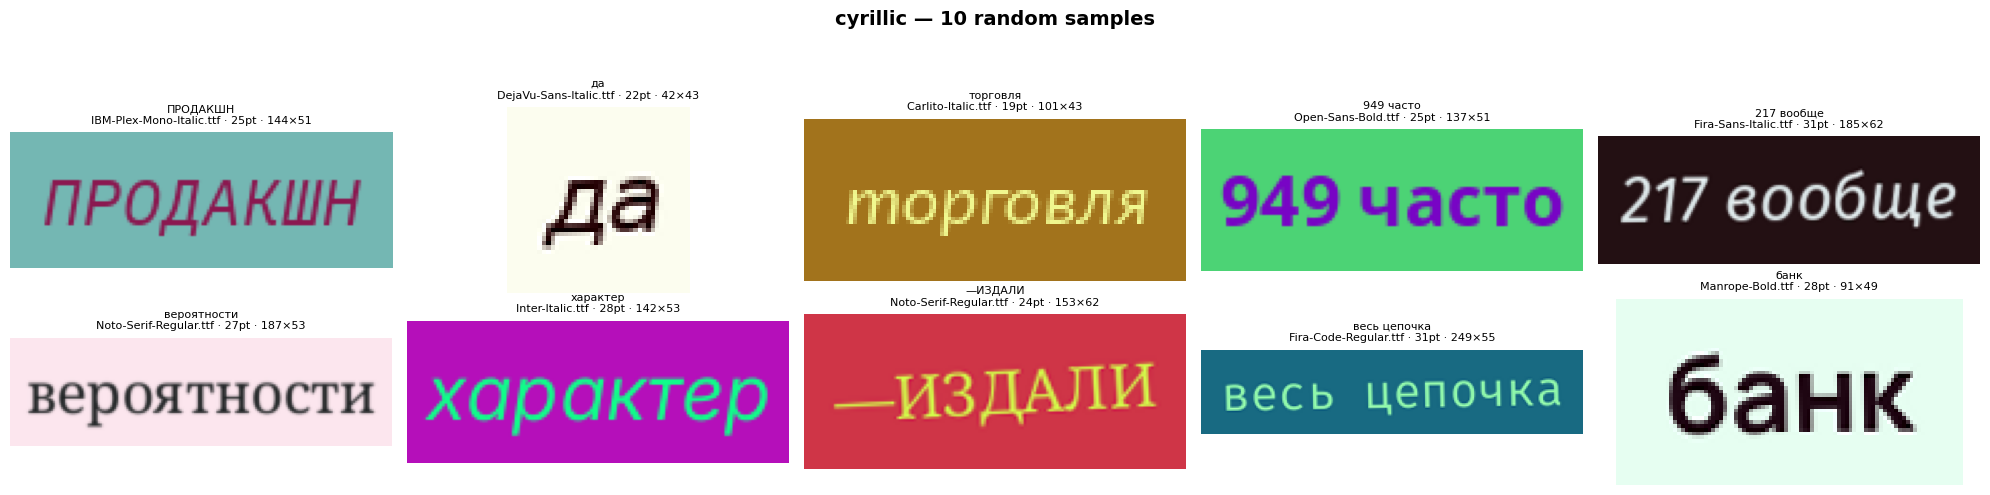

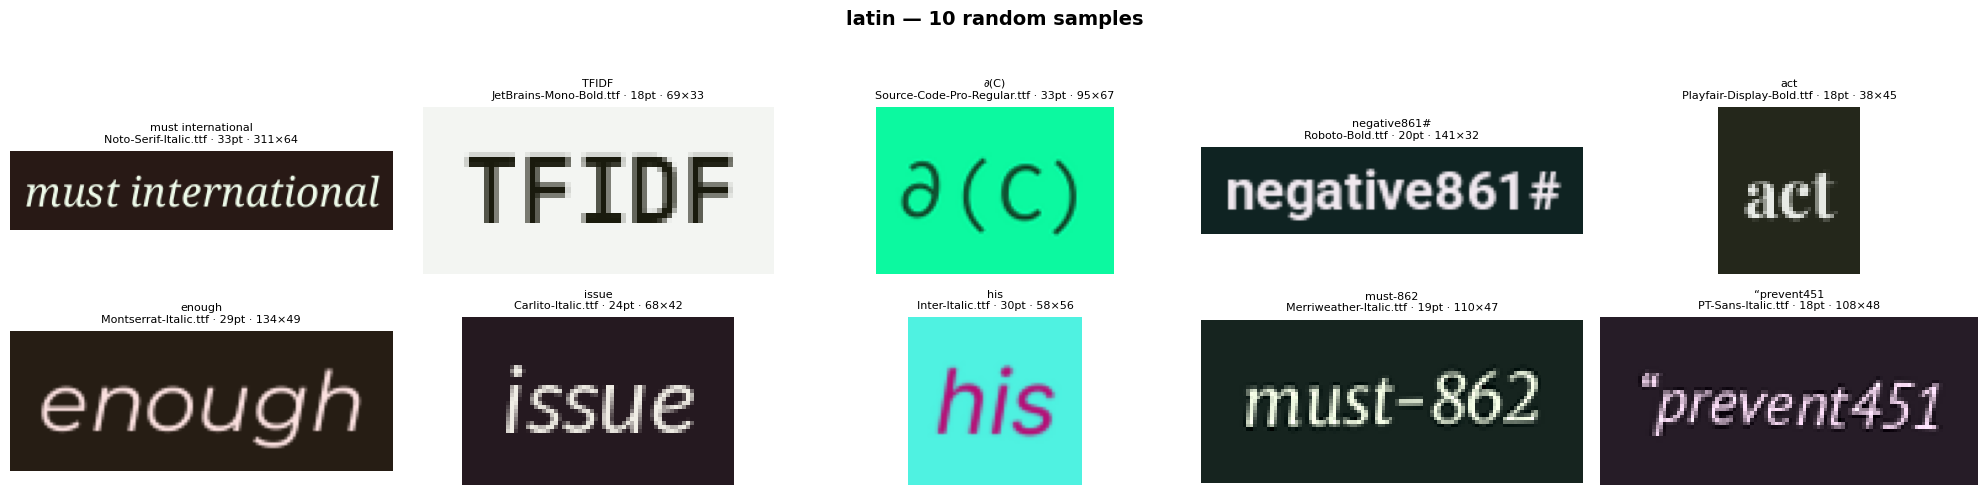

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

manifest_path = f"{DATASET_DIR}/dataset_manifest.csv"
df = pd.read_csv(manifest_path)

def show_samples(df, label, n=10):
    subset = df[df["label"] == label].sample(n=n).reset_index(drop=True)

    fig, axes = plt.subplots(2, 5, figsize=(20, 5))
    fig.suptitle(f"{label} — {n} random samples", fontsize=14, fontweight="bold")

    for ax, (_, row) in zip(axes.flat, subset.iterrows()):
        img = Image.open(f"{DATASET_DIR}/{row['filepath']}")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"{row['text']}\n"
            f"{row['font_name']} · {row['font_size']}pt · {row['width']}×{row['height']}",
            fontsize=8,
        )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

show_samples(df, "cyrillic", n=10)
show_samples(df, "latin",    n=10)

### Push to Hugging Face

In [9]:
def push_to_hf():
    import pandas as pd
    from datasets import Dataset, DatasetDict, Image as HFImage
    from huggingface_hub import login

    login(token=HF_TOKEN)

    df = pd.read_csv(f"{DATASET_DIR}/dataset_manifest.csv")
    df["image"] = df["filepath"].apply(lambda x: f"{DATASET_DIR}/{x}")

    ds = Dataset.from_pandas(df).cast_column("image", HFImage())

    splits = DatasetDict({
        "train": ds.filter(lambda x: x["split"] == "train"),
        "val":   ds.filter(lambda x: x["split"] == "val"),
        "test":  ds.filter(lambda x: x["split"] == "test"),
    })

    splits.push_to_hub(HF_REPO)
    print(f"Pushed to https://huggingface.co/datasets/{HF_REPO}")


push_to_hf()

Filter:   0%|          | 0/400000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/400000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/400000 [00:00<?, ? examples/s]

Uploading the dataset shards:   0%|          | 0/3 [00:00<?, ? shards/s]

Map:   0%|          | 0/106819 [00:00<?, ? examples/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmp7k_y7731.parquet    :   0%|          |  528kB /  144MB            

/usr/local/lib/python3.13/dist-packages/huggingface_hub/hf_api.py:11708: UserWarning: Warnings while validating metadata in README.md:
- The task_categories "optical-character-recognition" is not in the official list: text-classification, token-classification, table-question-answering, question-answering, zero-shot-classification, translation, summarization, feature-extraction, text-generation, fill-mask, sentence-similarity, text-to-speech, text-to-audio, automatic-speech-recognition, audio-to-audio, audio-classification, audio-text-to-text, voice-activity-detection, depth-estimation, image-classification, object-detection, image-segmentation, text-to-image, image-to-text, image-to-image, image-to-video, unconditional-image-generation, video-classification, reinforcement-learning, robotics, tabular-classification, tabular-regression, tabular-to-text, table-to-text, multiple-choice, text-ranking, text-retrieval, time-series-forecasting, text-to-video, image-text-to-text, image-text-to-

Pushed to https://huggingface.co/datasets/tehnik-tehnolog/bilingual-ocr-ru-en-synthetic
